[*] HackRF: 917.000 MHz; señal: 917.500 MHz
[*] Grabando 10.0 segundos...
[+] Captura guardada: /home/alanastasio/repos/auto/demodulador/demodulador/research/LoRa/captures/lora_20260921_192733_630251.npz
[+] 20054016 muestras (10.027008 s), SF=12, BW=500 kHz, Os=4


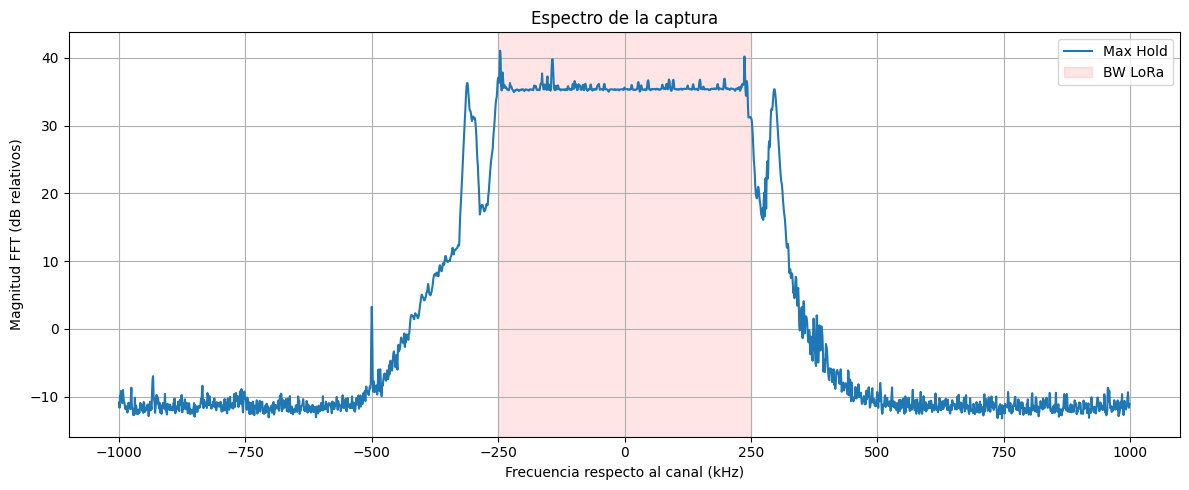

In [41]:
import os
import sys
import time
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import matplotlib.pyplot as plt

# 1. CAPTURA / REPRODUCCIÓN Y ESPECTRO MAX HOLD
# None: tomar una captura nueva y guardarla automáticamente en captures/.
# Para repetir un análisis, usar por ejemplo 'captures/lora_20260921_....npz'.
CAPTURE_FILE = None             #os.environ.get('LORA_CAPTURE_FILE') or None
SAVE_CAPTURE = True
sample_rate = 2e6
target_freq = 917.5e6
offset_freq = 0.5e6
center_freq = target_freq - offset_freq
BW = 500e3
SF = 12
LDRO = False  # Debe coincidir con el transmisor; SF8/BW500 no requiere LDRO.
duration = 10.0  # El transmisor repite cada 5 s: normalmente se capturan dos paquetes.
frame_synced = header_valid = payload_valid = False
detected_window = -1
payload_bytes = None

notebook_dir = next((p for p in (Path.cwd(), Path.cwd() / 'demodulador/research/LoRa',
                                 Path.cwd() / 'research/LoRa')
                     if (p / 'captura_y_demod_LORA.ipynb').is_file()), None)
if notebook_dir is None:
    raise RuntimeError('Ejecutar desde la carpeta LoRa o desde la raíz del proyecto.')

if CAPTURE_FILE is not None:
    capture_path = Path(CAPTURE_FILE).expanduser()
    if not capture_path.is_absolute():
        capture_path = notebook_dir / capture_path
    with np.load(capture_path, allow_pickle=False) as saved:
        iq_raw = saved['raw_iq'].astype(np.complex64)
        sample_rate = float(saved['sample_rate'])
        center_freq = float(saved['center_freq'])
        target_freq = float(saved['target_freq']) if 'target_freq' in saved else target_freq
        BW = float(saved['BW']) if 'BW' in saved else BW
        SF = int(saved['SF']) if 'SF' in saved else SF
        LDRO = bool(saved['LDRO']) if 'LDRO' in saved else LDRO
    print(f'[*] Captura cargada: {capture_path}')
else:
    # El driver sólo se importa al capturar; el análisis offline no necesita una HackRF.
    sys.path.insert(0, str(notebook_dir.parents[1]))
    from hardware.hackrf_handler import HackRFHandler

    captured_samples = []
    capture_active = False
    def rx_callback(samples):
        if capture_active:
            captured_samples.append(samples.astype(np.complex64, copy=True))

    sdr = HackRFHandler(rx_callback)
    try:
        sdr.configurar(sample_rate, center_freq)
        sdr.set_gain(16)
        sdr.set_vga_gain(20)
        print(f'[*] HackRF: {center_freq/1e6:.3f} MHz; señal: {target_freq/1e6:.3f} MHz')
        sdr.start_rx()
        time.sleep(2.0)
        captured_at = datetime.now(timezone.utc)
        capture_active = True
        print(f'[*] Grabando {duration:.1f} segundos...')
        time.sleep(duration)
    finally:
        capture_active = False
        sdr.close()  # close() ya llama stop_rx(); evitar detener dos veces.
    if not captured_samples:
        raise RuntimeError('La HackRF no entregó muestras.')
    iq_raw = np.concatenate(captured_samples)
    captured_samples.clear()
    capture_path = None
    if SAVE_CAPTURE:
        captures_dir = notebook_dir / 'captures'
        captures_dir.mkdir(exist_ok=True)
        capture_path = captures_dir / f'lora_{captured_at:%Y%m%d_%H%M%S_%f}.npz'
        np.savez_compressed(capture_path, raw_iq=iq_raw, sample_rate=sample_rate,
                            center_freq=center_freq, target_freq=target_freq,
                            BW=BW, SF=SF, LDRO=LDRO, dc_removed=False,
                            captured_at_utc=captured_at.isoformat())
        print(f'[+] Captura guardada: {capture_path}')

if iq_raw.ndim != 1 or not np.iscomplexobj(iq_raw) or len(iq_raw) < 2048:
    raise ValueError('Se requiere una captura IQ compleja unidimensional de al menos 2048 muestras.')
if not 7 <= SF <= 12 or BW <= 0 or sample_rate <= 0:
    raise ValueError('Este notebook admite LoRa con header explícito, SF7 a SF12 y tasas positivas.')
N = 2**SF
Os = int(round(sample_rate / BW))
if Os < 1 or not np.isclose(sample_rate / BW, Os):
    raise ValueError('La tasa de muestreo debe ser un múltiplo entero del BW.')
N_sym = N * Os
T_sym = N / BW
offset_freq = target_freq - center_freq
if abs(offset_freq) + BW/2 >= sample_rate/2:
    raise ValueError('El canal LoRa no queda dentro de la banda de Nyquist de la captura.')
print(f'[+] {len(iq_raw)} muestras ({len(iq_raw)/sample_rate:.6f} s), SF={SF}, BW={BW/1e3:.0f} kHz, Os={Os}')

# Conservar iq_raw sin alterar. Eliminar DC y desplazar a banda base por bloques.
iq_base = np.empty(len(iq_raw), dtype=np.complex64)
dc = np.mean(iq_raw, dtype=np.complex128)
for begin in range(0, len(iq_raw), 262144):
    end = min(begin + 262144, len(iq_raw))
    iq_base[begin:end] = (iq_raw[begin:end] - dc) * np.exp(
        -2j * np.pi * offset_freq * np.arange(begin, end) / sample_rate)

t_chirp = np.arange(N_sym) / sample_rate
phase_up = 2*np.pi * (-BW/2*t_chirp + BW/(2*T_sym)*t_chirp**2)
base_up_chirp = np.exp(1j * phase_up)
base_down = np.conj(base_up_chirp)

nfft = 2048
max_hold = np.full(nfft, -np.inf)
window = np.blackman(nfft)
for begin in range(0, len(iq_base) - nfft + 1, nfft):
    spectrum = np.fft.fftshift(np.fft.fft(iq_base[begin:begin+nfft] * window))
    max_hold = np.maximum(max_hold, 20*np.log10(np.abs(spectrum) + 1e-12))
freqs = np.fft.fftshift(np.fft.fftfreq(nfft, d=1/sample_rate)) / 1e3
plt.figure(figsize=(12, 5))
plt.plot(freqs, max_hold, label='Max Hold')
plt.axvspan(-BW/2e3, BW/2e3, color='red', alpha=0.1, label='BW LoRa')
plt.xlabel('Frecuencia respecto al canal (kHz)'); plt.ylabel('Magnitud FFT (dB relativos)')
plt.title('Espectro de la captura'); plt.grid(); plt.legend(); plt.tight_layout(); plt.show()


[*] Ejecutando Detección Gruesa del Preámbulo según guía matemática...
[*] Procesando 4893 ventanas (Stride=4096 muestras)...
[+] ¡Preámbulo detectado! Inicio aproximado en la muestra 1871872
[+] Bin detectado (combina CFO y desfase temporal): 15116
[+] PAPR de la primera ventana: 6994.39


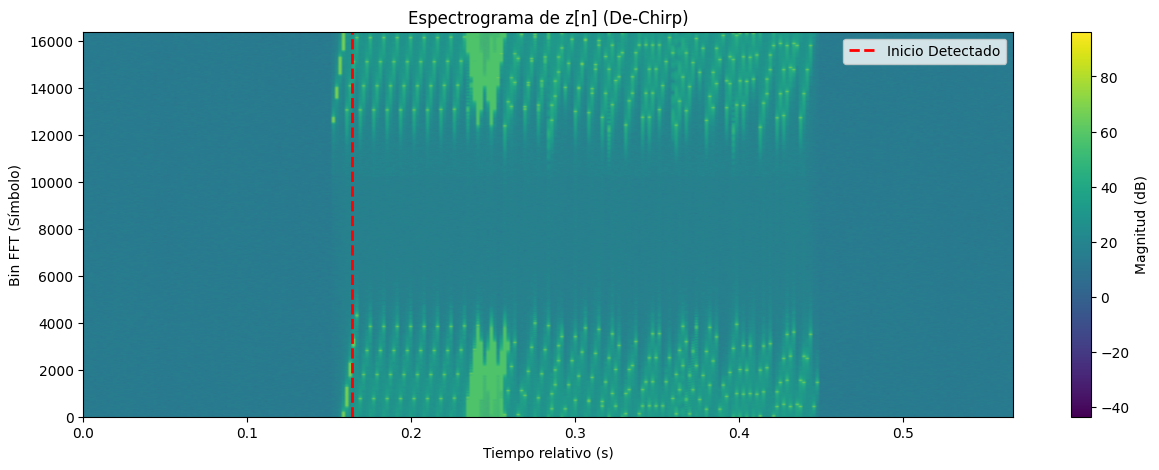

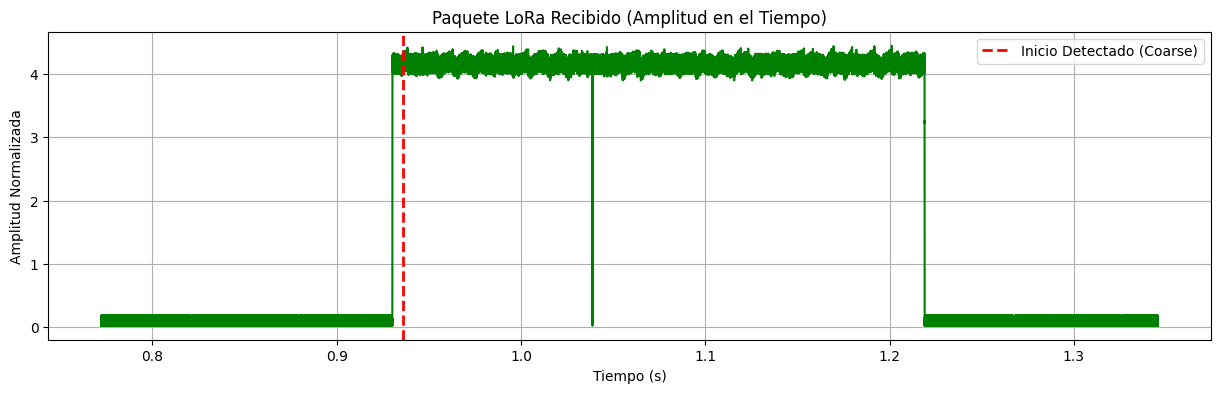

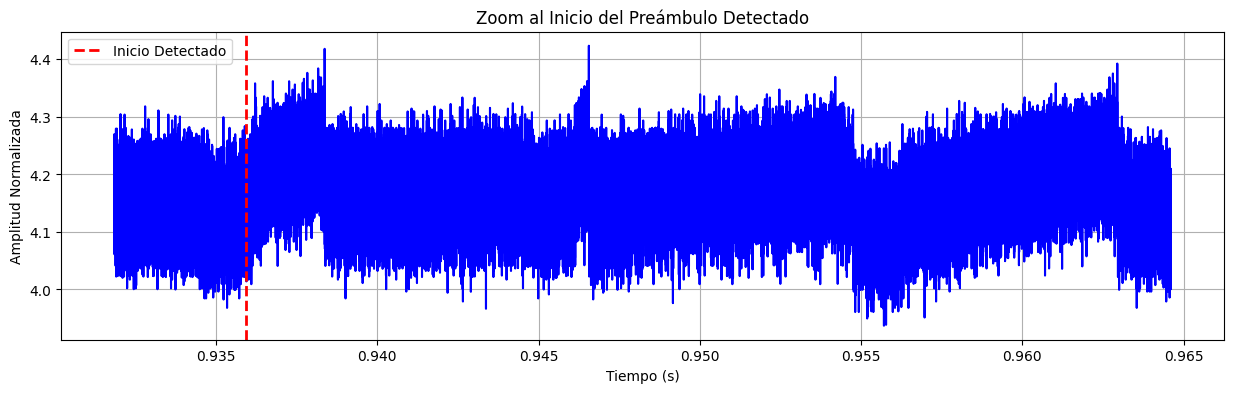

In [42]:
# ============================================================
# 2. ETAPA 1: DETECCIÓN GRUESA DEL PREÁMBULO (Sliding Window)
# ============================================================

print("[*] Ejecutando Detección Gruesa del Preámbulo según guía matemática...")

# 1. Normalización de Ganancia
frame_synced = header_valid = payload_valid = False
detected_window = -1
coarse_start_idx = None
payload_bytes = None
scale = float(np.std(iq_base))
if not np.isfinite(scale) or scale <= 0:
    raise ValueError('La captura está vacía, es constante o contiene valores no finitos.')
iq_norm = iq_base / scale
# Seleccionar otro paquete de la misma captura sin volver a recibir por RF.
DETECTION_START_SECONDS = 0.0

# Parámetros del algoritmo de ventana deslizante
N_samples = N_sym
h = N_samples // 4  # Zancada de N_samples / 4
PAPR_THRESHOLD = 10.0
M = 4 # Número de símbolos consecutivos requeridos

num_windows = max(0, 1 + (len(iq_norm) - N_samples) // h)
papr_history = np.zeros(num_windows)
bin_history = np.zeros(num_windows, dtype=int)

print(f"[*] Procesando {num_windows} ventanas (Stride={h} muestras)...")
for i in range(num_windows):
    start_idx = i * h
    window_iq = iq_norm[start_idx : start_idx + N_samples]
    
    # De-chirping
    z = window_iq * base_down
    
    # FFT
    Z = np.fft.fft(z)
    Z_mag_sq = np.abs(Z)**2
    
    # Métrica de Detección (PAPR)
    max_Z_sq = np.max(Z_mag_sq)
    avg_Z_sq = np.mean(Z_mag_sq)
    papr = max_Z_sq / max(avg_Z_sq, 1e-30)
    
    papr_history[i] = papr
    bin_history[i] = np.argmax(Z_mag_sq)

# Búsqueda de M símbolos consecutivos en la misma alineación
# Como el salto es N_samples/4, un símbolo entero son 4 ventanas.
stride_per_sym = N_samples // h
detected_window = -1

first_window = max(0, int(DETECTION_START_SECONDS * sample_rate / h))
for i in range(first_window, num_windows - (M - 1) * stride_per_sym):
    if papr_history[i] < PAPR_THRESHOLD:
        continue
        
    target_bin = bin_history[i]
    valid = True
    for m in range(1, M):
        idx = i + m * stride_per_sym
        # Tolerancia de +-2 bins por ruido/CFO fraccional
        bin_diff = abs(bin_history[idx] - target_bin)
        bin_diff = min(bin_diff, N_samples - bin_diff)
        
        if papr_history[idx] < PAPR_THRESHOLD or bin_diff > 2:
            valid = False
            break
            
    if valid:
        detected_window = i
        break

if detected_window != -1:
    coarse_start_idx = detected_window * h
    print(f"[+] ¡Preámbulo detectado! Inicio aproximado en la muestra {coarse_start_idx}")
    print(f"[+] Bin detectado (combina CFO y desfase temporal): {bin_history[detected_window]}")
    print(f"[+] PAPR de la primera ventana: {papr_history[detected_window]:.2f}")
else:
    print("[-] No se detectó ningún preámbulo.")
    coarse_start_idx = None
    raise RuntimeError("No se detectó preámbulo; revisar SF/BW o tomar otra captura.")

# ============================================================
# GRÁFICOS
# ============================================================
if detected_window != -1:
    # 0. Espectrograma del De-Chirp (FFT de z) alrededor del paquete
    # Calculamos el espectrograma de la señal de-chirped solo en la región del paquete
    burst_len = int(50 * N_samples)
    start_plot = max(0, coarse_start_idx - 20 * N_samples)
    end_plot = min(len(iq_norm), coarse_start_idx + burst_len)
    
    spec_windows = 1 + (end_plot - start_plot - N_samples) // h
    spectrogram = np.zeros((N_samples, spec_windows))
    
    for w in range(spec_windows):
        idx = start_plot + w * h
        chunk = iq_norm[idx : idx + N_samples]
        z_chunk = chunk * base_down
        Z_mag = 20 * np.log10(np.abs(np.fft.fft(z_chunk)) + 1e-12)
        spectrogram[:, w] = Z_mag
        
    plt.figure(figsize=(15, 5))
    plt.imshow(spectrogram, aspect='auto', origin='lower', cmap='viridis', 
               extent=[0, spec_windows * h / sample_rate, 0, N_samples])
    plt.axvline((coarse_start_idx - start_plot) / sample_rate, color='red', linestyle='--', linewidth=2, label='Inicio Detectado')
    plt.title('Espectrograma de z[n] (De-Chirp)')
    plt.xlabel('Tiempo relativo (s)')
    plt.ylabel('Bin FFT (Símbolo)')
    plt.colorbar(label='Magnitud (dB)')
    plt.legend()
    plt.show()
    
    # 1. Gráfico en el tiempo del paquete completo recibido
    # Ventana de visualización: 50 símbolos; no determina la longitud del paquete
    burst_len = int(50 * N_samples)
    start_plot = max(0, coarse_start_idx - 20 * N_samples)
    end_plot = min(len(iq_norm), coarse_start_idx + burst_len)
    
    t_paquete = np.arange(start_plot, end_plot) / sample_rate
    paquete_iq = iq_norm[start_plot:end_plot]
    
    plt.figure(figsize=(15, 4))
    plt.plot(t_paquete, np.abs(paquete_iq), color='green')
    plt.axvline(coarse_start_idx / sample_rate, color='red', linestyle='--', linewidth=2, label='Inicio Detectado (Coarse)')
    plt.title('Paquete LoRa Recibido (Amplitud en el Tiempo)')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud Normalizada')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    # 2. Gráfico con Zoom al inicio detectado (4 símbolos)
    zoom_start = max(0, coarse_start_idx - int(0.5 * N_samples))
    zoom_end = min(len(iq_norm), coarse_start_idx + int(3.5 * N_samples))
    
    t_zoom = np.arange(zoom_start, zoom_end) / sample_rate
    zoom_iq = iq_norm[zoom_start:zoom_end]
    
    plt.figure(figsize=(15, 4))
    plt.plot(t_zoom, np.abs(zoom_iq), color='blue')
    plt.axvline(coarse_start_idx / sample_rate, color='red', linestyle='--', linewidth=2, label='Inicio Detectado')
    plt.title('Zoom al Inicio del Preámbulo Detectado')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Amplitud Normalizada')
    plt.legend()
    plt.grid(True)
    plt.show()


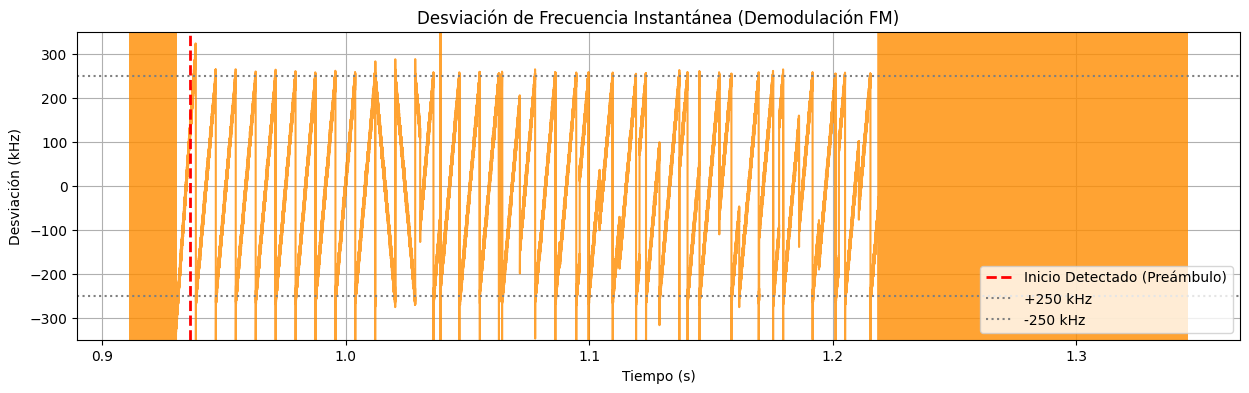

In [43]:
# ============================================================
# 3. DEMODULACIÓN FM (FRECUENCIA INSTANTÁNEA)
# ============================================================

if detected_window != -1:
    start_fm = max(0, coarse_start_idx - 3 * N_samples)
    burst_len = int(50 * N_samples)
    end_fm = min(len(iq_norm), coarse_start_idx + burst_len)
    
    iq_fm = iq_norm[start_fm:end_fm]
    t_fm = np.arange(start_fm, end_fm - 1) / sample_rate
    
    # Demodulación FM vectorizada (Derivada de la fase matemática)
    # f_inst[n] = Fs / (2*pi) * arg( x[n] * conj(x[n-1]) )
    f_inst = np.angle(iq_fm[1:] * np.conjugate(iq_fm[:-1])) * (sample_rate / (2 * np.pi))
    
    plt.figure(figsize=(15, 4))
    plt.plot(t_fm, f_inst / 1e3, color='darkorange', alpha=0.8)
    plt.axvline(coarse_start_idx / sample_rate, color='red', linestyle='--', linewidth=2, label='Inicio Detectado (Preámbulo)')
    plt.axhline(250, color='gray', linestyle=':', label='+250 kHz')
    plt.axhline(-250, color='gray', linestyle=':', label='-250 kHz')
    
    plt.title('Desviación de Frecuencia Instantánea (Demodulación FM)')
    plt.xlabel('Tiempo (s)')
    plt.ylabel('Desviación (kHz)')
    plt.ylim(-350, 350)
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("[-] Preámbulo no detectado, se omite el gráfico de FM.")


[+] CFO estimado: -6329.22 Hz; ajuste temporal: 4864 muestras
[+] Referencia temporal: muestra 1876736; SFD observado cerca del símbolo 9


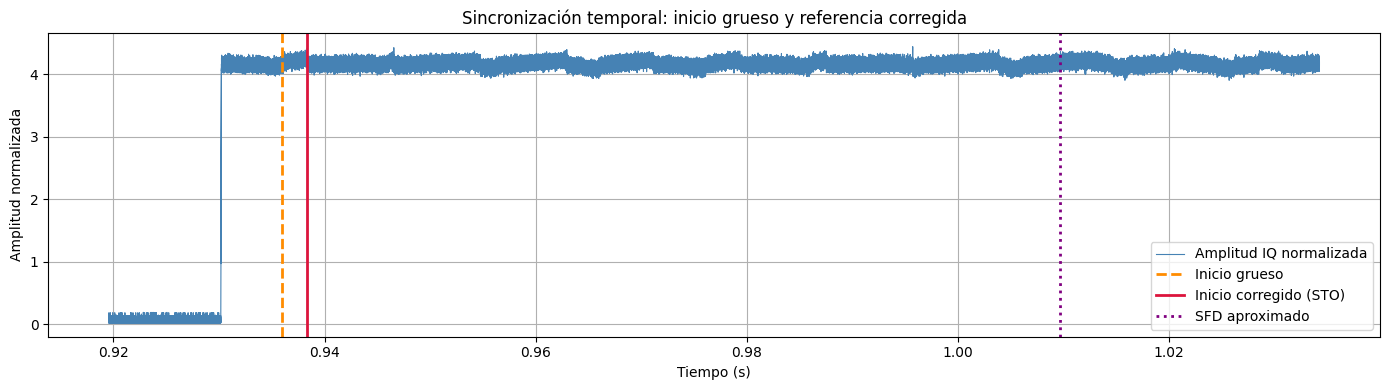

In [48]:
# 4. SINCRONIZACIÓN CFO/STO A PARTIR DE UPCHIRPS Y SFD OBSERVADOS
# Las frecuencias de los chirps se buscan en la FFT completa, incluidos bins negativos.
frame_synced = False
header_valid = False
payload_valid = False
if detected_window == -1:
    raise RuntimeError('No hay preámbulo; ejecutar nuevamente la detección o capturar otra señal.')

def fft_chirp(samples, reference, interpolation=1):
    if len(samples) != N_sym:
        raise ValueError('Símbolo incompleto en la captura.')
    power = np.abs(np.fft.fft(samples * reference, n=N_sym * interpolation)) ** 2
    index = int(np.argmax(power))
    signed_bin = ((index + len(power) // 2) % len(power) - len(power) // 2) / interpolation
    concentration = float(power[index] / max(N_sym * np.vdot(samples, samples).real, 1e-30))
    return signed_bin, concentration

def folded_power(samples, reference=base_down):
    if len(samples) != N_sym:
        raise ValueError('Símbolo incompleto en la captura.')
    power = np.abs(np.fft.fft(samples * reference)) ** 2
    return power.reshape(Os, N).sum(axis=0)

def circular_bin_distance(a, b, size=N):
    return abs((a - b + size / 2) % size - size / 2)

# Todas las ventanas comparten la misma fase temporal (separación de un símbolo).
# El límite es una ventana de búsqueda, no una longitud fija de preámbulo.
scan = []
for k in range(1, 69):
    idx = coarse_start_idx + k * N_sym
    if idx + N_sym > len(iq_norm):
        break
    chunk = iq_norm[idx:idx + N_sym]
    ku, qu = fft_chirp(chunk, base_down)
    kd, qd = fft_chirp(chunk, base_up_chirp)
    scan.append((k, ku, qu, kd, qd))

# Con alineación gruesa sólo hay garantizada una ventana completa dentro del SFD.
# La confirmación de sus dos downchirps se hace después de corregir STO, en la celda 5.
sfd_candidates = [i for i, row in enumerate(scan)
                  if row[4] > 0.03 and row[4] > 4 * row[2]]
if not sfd_candidates:
    raise RuntimeError('No se encontró un downchirp del SFD después del preámbulo.')
sfd_scan = sfd_candidates[0]
down_row = scan[sfd_scan]
# Excluir los dos símbolos de sync word anteriores al SFD.
up_rows = [row for row in scan[:max(0, sfd_scan - 2)]
           if row[2] > 0.03 and row[2] > 3 * row[4]
           and circular_bin_distance(row[1], bin_history[detected_window], N_sym) <= 2]
if len(up_rows) < 3:
    raise RuntimeError('No hay suficientes upchirps repetidos para estimar CFO/STO.')

up_bins = []
phase_pairs = []
for row in up_rows:
    idx = coarse_start_idx + row[0] * N_sym
    chunk = iq_norm[idx:idx + N_sym]
    up_bins.append(fft_chirp(chunk, base_down, interpolation=32)[0])
for left, right in zip(up_rows, up_rows[1:]):
    if right[0] == left[0] + 1:
        a = coarse_start_idx + left[0] * N_sym
        cross = np.vdot(iq_norm[a:a + N_sym], iq_norm[a + N_sym:a + 2 * N_sym])
        if abs(cross) > 0:
            phase_pairs.append(cross / abs(cross))
if not phase_pairs:
    raise RuntimeError('No hay pares consecutivos de preámbulo para el CFO fraccional.')

ku = float(np.median(up_bins))
down_idx = coarse_start_idx + down_row[0] * N_sym
kd = fft_chirp(iq_norm[down_idx:down_idx + N_sym], base_up_chirp, interpolation=32)[0]
fractional_cfo_bin = np.angle(np.sum(phase_pairs)) / (2 * np.pi)
# Las ramas separadas por N bins corresponden al wrap del chirp sobremuestreado.
# El offset tuning deja el CFO dentro de +/- BW/4; fuera de ese rango se rechaza.
solutions = []
for branch_up in (-N, 0, N):
    for branch_down in (-N, 0, N):
        cfo_pair = (ku + branch_up + kd + branch_down) / 2
        cfo_bins = round(cfo_pair - fractional_cfo_bin) + fractional_cfo_bin
        timing = (ku + branch_up - cfo_bins) * Os
        if abs(cfo_bins) < N / 4 and abs(timing) <= N_sym / 2:
            solutions.append((abs(cfo_pair - cfo_bins), cfo_bins, timing))
if not solutions:
    raise RuntimeError('CFO/STO fuera del rango admitido; revisar frecuencia central y BW.')
_, cfo_bins, timing_samples = min(solutions)
df_total = cfo_bins / T_sym
true_start_idx = coarse_start_idx - int(round(timing_samples))
if true_start_idx < 0:
    raise RuntimeError('El preámbulo comienza antes de la captura.')

# Corregir por bloques evita temporales enormes durante los 10 segundos de captura.
iq_synced = np.empty(len(iq_norm), dtype=np.complex64)
for begin in range(0, len(iq_norm), 262144):
    end = min(begin + 262144, len(iq_norm))
    iq_synced[begin:end] = iq_norm[begin:end] * np.exp(
        -2j * np.pi * df_total * np.arange(begin, end) / sample_rate)
frame_synced = True
print(f'[+] CFO estimado: {df_total:.2f} Hz; ajuste temporal: {true_start_idx - coarse_start_idx} muestras')
print(f'[+] Referencia temporal: muestra {true_start_idx}; SFD observado cerca del símbolo {down_row[0]}')

# Visualización de la corrección temporal: permite comprobar el STO sobre la ráfaga.
plot_start = max(0, min(coarse_start_idx, true_start_idx) - 2 * N_sym)
plot_end = min(len(iq_norm), max(coarse_start_idx, true_start_idx,
                                  coarse_start_idx + (down_row[0] + 1) * N_sym) + 2 * N_sym)
plot_idx = np.arange(plot_start, plot_end)
plt.figure(figsize=(14, 4))
plt.plot(plot_idx / sample_rate, np.abs(iq_norm[plot_start:plot_end]),
         color='steelblue', linewidth=0.8, label='Amplitud IQ normalizada')
plt.axvline(coarse_start_idx / sample_rate, color='darkorange', linestyle='--',
            linewidth=2, label='Inicio grueso')
plt.axvline(true_start_idx / sample_rate, color='crimson', linestyle='-',
            linewidth=2, label='Inicio corregido (STO)')
# down_row[0] cuenta desde coarse_start_idx, no desde true_start_idx.
sfd_coarse_idx = coarse_start_idx + down_row[0] * N_sym
plt.axvline(sfd_coarse_idx / sample_rate,
            color='purple', linestyle=':', linewidth=2, label='SFD aproximado')
plt.xlabel('Tiempo (s)'); plt.ylabel('Amplitud normalizada')
plt.title('Sincronización temporal: inicio grueso y referencia corregida')
plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


[*] Deriva residual: -0.031250 bins/símbolo; 7 upchirps de referencia
[+] Sync word: 0x34; símbolos: [24, 32]
[+] Residuo del preámbulo: 0 bins
[+] SFD: muestra 2024192; header: 2061056; siguiente bloque: 2192128
  Offset |   Bin up |  Conc. up | Conc. down
      -1 |     3606 |     0.001 |      0.000
       0 |        0 |     0.954 |      0.000
       1 |        0 |     0.970 |      0.000
       2 |        0 |     0.984 |      0.000
       3 |        0 |     0.991 |      0.000
       4 |        0 |     0.995 |      0.000
       5 |        0 |     0.989 |      0.000
       6 |        0 |     0.983 |      0.000
       7 |       24 |     0.957 |      0.000
       8 |       32 |     0.937 |      0.000
       9 |       72 |     0.000 |      0.933
      10 |       84 |     0.000 |      0.911
      11 |      345 |     0.412 |      0.059
      12 |     3213 |     0.499 |      0.001
      13 |     3105 |     0.496 |      0.001


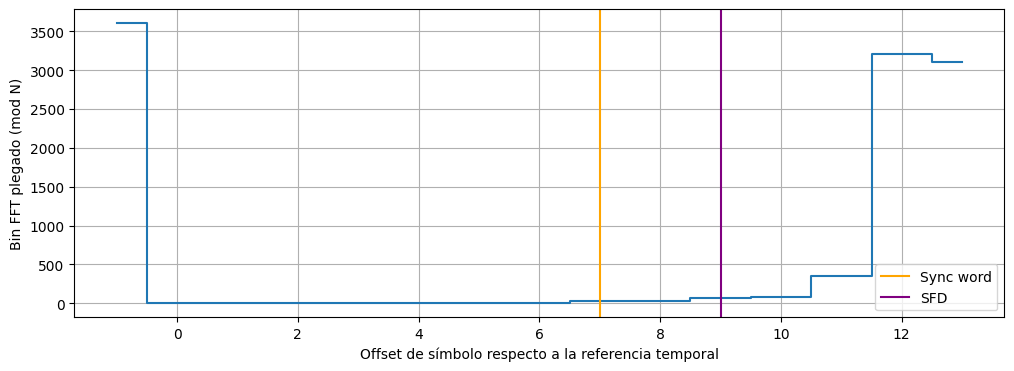

In [45]:
# 5. SYNC WORD Y POSICIÓN DEL SFD: NO SE ASUME UN OFFSET FIJO
header_valid = False
payload_valid = False
if not frame_synced:
    raise RuntimeError('Ejecutar primero la sincronización CFO/STO.')

sym_offsets = list(range(-1, min(69, (len(iq_synced) - true_start_idx) // N_sym)))
rows = []
for k in sym_offsets:
    idx = true_start_idx + k * N_sym
    if idx < 0:
        rows.append((k, None, 0.0, 0.0))
        continue
    chunk = iq_synced[idx:idx + N_sym]
    pu = folded_power(chunk)
    pd = folded_power(chunk, base_up_chirp)
    energy = max(float(N_sym * np.vdot(chunk, chunk).real), 1e-30)
    rows.append((k, int(np.argmax(pu)), float(pu.max()/energy), float(pd.max()/energy)))

# Localizar primero dos downchirps fuertes; sus dos predecesores son la sync word.
frame_candidates = []
for j in range(6, len(rows) - 1):
    if not all(r[3] > 0.1 and r[3] > 4 * r[2] for r in rows[j:j + 2]):
        continue
    preamble_rows = rows[j - 6:j - 2]
    if not all(r[1] is not None and r[2] > 0.1 and r[2] > 4*r[3] for r in preamble_rows):
        continue
    anchor = preamble_rows[0][1]
    if not all(circular_bin_distance(r[1], anchor) <= 1 for r in preamble_rows):
        continue
    # Residuo entero medido en el preámbulo, nunca ajustado buscando un checksum.
    signed = [((r[1] + N//2) % N) - N//2 for r in preamble_rows]
    residual_bin = int(round(float(np.median(signed))))
    sync_symbols = [(rows[j - 2 + m][1] - residual_bin) % N for m in (0, 1)]
    sync_nibbles = [int(round(s / 8)) for s in sync_symbols]
    if not all(0 <= nib <= 15 and circular_bin_distance(sym, 8*nib) <= 1
               for sym, nib in zip(sync_symbols, sync_nibbles)):
        continue
    frame_candidates.append((j, residual_bin, sync_symbols, sync_nibbles))
    break
if not frame_candidates:
    frame_synced = False
    raise RuntimeError('No se validó la secuencia preámbulo / sync word / SFD.')

j, preamble_bin_offset, sync_symbols, sync_nibbles = frame_candidates[0]
sync_word = (sync_nibbles[0] << 4) | sync_nibbles[1]
sfd_start_offset = rows[j][0]
sfd_start_idx = true_start_idx + sfd_start_offset * N_sym
header_start_idx = sfd_start_idx + 2 * N_sym + N_sym // 4
payload_start_idx = header_start_idx + 8 * N_sym

# Medir la deriva residual en todos los upchirps válidos anteriores a la sync word.
# En SF altos, una deriva pequeña puede superar medio bin durante header/payload.
# El ajuste usa sólo pilotos conocidos; no depende de los datos ni del checksum.
pilot_rows = [r for r in rows[:j - 2]
              if r[1] is not None and r[2] > 0.1 and r[2] > 4*r[3]
              and circular_bin_distance(r[1], preamble_bin_offset) <= 1]
if len(pilot_rows) < 4:
    frame_synced = False
    raise RuntimeError('Faltan upchirps válidos para medir la deriva residual.')
pilot_offsets = np.array([r[0] for r in pilot_rows], dtype=float)
pilot_bins = np.array([
    fft_chirp(iq_synced[true_start_idx + int(k)*N_sym:
                        true_start_idx + (int(k)+1)*N_sym],
              base_down, interpolation=32)[0]
    for k in pilot_offsets])
pilot_reference_offset = float(np.mean(pilot_offsets))
frequency_drift_bins_per_symbol, pilot_frequency_at_reference = np.polyfit(
    pilot_offsets - pilot_reference_offset, pilot_bins, 1)
# Incluye tanto el residuo entero como el fraccional de CFO/STO.
def residual_frequency_bins(sample_idx):
    symbol_offset = (sample_idx - true_start_idx) / N_sym
    return float(pilot_frequency_at_reference + frequency_drift_bins_per_symbol *
                 (symbol_offset - pilot_reference_offset))

print(f'[*] Deriva residual: {frequency_drift_bins_per_symbol:+.6f} bins/símbolo; '
      f'{len(pilot_rows)} upchirps de referencia')
print(f'[+] Sync word: 0x{sync_word:02X}; símbolos: {sync_symbols}')
print(f'[+] Residuo del preámbulo: {preamble_bin_offset} bins')
print(f'[+] SFD: muestra {sfd_start_idx}; header: {header_start_idx}; siguiente bloque: {payload_start_idx}')
print(f"{'Offset':>8} | {'Bin up':>8} | {'Conc. up':>9} | {'Conc. down':>10}")
for k, value, qu, qd in rows[:j + 5]:
    print(f'{k:8} | {str(value):>8} | {qu:9.3f} | {qd:10.3f}')
plt.figure(figsize=(12, 4))
plt.step([r[0] for r in rows[:j+5]], [np.nan if r[1] is None else r[1] for r in rows[:j+5]], where='mid')
plt.axvline(sfd_start_offset - 2, color='orange', label='Sync word')
plt.axvline(sfd_start_offset, color='purple', label='SFD')
plt.xlabel('Offset de símbolo respecto a la referencia temporal')
plt.ylabel('Bin FFT plegado (mod N)')
plt.grid(); plt.legend(); plt.show()


In [46]:
# 6. PHY HEADER: GRAY, DESENTRELAZADO Y HAMMING CON UN ÚNICO ORDEN DE BITS
# Convención compatible con gr-lora_sdr (deinterleaver_impl / hamming_enc_impl).
# https://github.com/tapparelj/gr-lora_sdr/tree/master/lib
header_valid = False
payload_valid = False
decoded_L = decoded_cr = decoded_has_crc = None
header_payload_nibbles = []
if not frame_synced:
    raise RuntimeError('No hay una trama sincronizada.')

def deinterleave(symbols, sf_app):
    words = [[0] * len(symbols) for _ in range(sf_app)]
    for i, symbol in enumerate(symbols):
        gray = int(symbol) ^ (int(symbol) >> 1)
        for j in range(sf_app):
            words[(i - j - 1) % sf_app][i] = (gray >> (sf_app - 1 - j)) & 1
    return [sum(bit << (len(row) - 1 - i) for i, bit in enumerate(row)) for row in words]

def hamming_codeword(nibble, cr):
    d0, d1, d2, d3 = [(nibble >> k) & 1 for k in range(4)]
    parity = ([d0 ^ d1 ^ d2 ^ d3] if cr == 1 else
              [d0 ^ d1 ^ d2, d1 ^ d2 ^ d3, d0 ^ d1 ^ d3, d0 ^ d2 ^ d3][:cr])
    bits = [d0, d1, d2, d3] + parity
    return sum(bit << (len(bits) - 1 - i) for i, bit in enumerate(bits))

def decode_hamming(words, cr):
    if cr not in (1, 2, 3, 4):
        raise ValueError('Coding rate inválido.')
    candidates = [hamming_codeword(nibble, cr) for nibble in range(16)]
    nibbles, distances = [], []
    for word in words:
        ds = [(int(word) ^ candidate).bit_count() for candidate in candidates]
        distance = min(ds)
        # CR 4/5 y 4/6 detectan errores; 4/7 y 4/8 corrigen un bit.
        if ds.count(distance) != 1 or distance > (1 if cr >= 3 else 0):
            raise ValueError(f'FEC no corregible o ambiguo: palabra 0x{word:X}, distancia {distance}.')
        nibbles.append(ds.index(distance))
        distances.append(distance)
    return nibbles, distances

def demod_symbols(start, count, reduced=False):
    if start < 0 or start + count * N_sym > len(iq_synced):
        raise ValueError('La captura termina antes de completar los símbolos solicitados.')
    symbols, peaks, concentrations = [], [], []
    for i in range(count):
        idx = start + i * N_sym
        # Centrar el pico con la deriva extrapolada desde el preámbulo.
        # Corregir antes de la FFT evita perder un bin al redondear sus picos.
        residual = residual_frequency_bins(idx)
        corrected = iq_synced[idx:idx + N_sym] * np.exp(
            -2j * np.pi * residual * np.arange(N_sym) / N_sym)
        power = folded_power(corrected)
        peak = int(np.argmax(power))
        value = (peak - 1) % N  # El residuo del preámbulo ya fue compensado.
        symbols.append(value // 4 if reduced else value)
        peaks.append(peak)
        concentrations.append(float(power.max() / max(power.sum(), 1e-30)))
    return symbols, peaks, concentrations

def header_checksum(n0, n1, n2):
    bit = lambda value, k: (value >> k) & 1
    c4 = bit(n0,3)^bit(n0,2)^bit(n0,1)^bit(n0,0)
    c3 = bit(n0,3)^bit(n1,3)^bit(n1,2)^bit(n1,1)^bit(n2,0)
    c2 = bit(n0,2)^bit(n1,3)^bit(n1,0)^bit(n2,3)^bit(n2,1)
    c1 = bit(n0,1)^bit(n1,2)^bit(n1,0)^bit(n2,2)^bit(n2,1)^bit(n2,0)
    c0 = bit(n0,0)^bit(n1,1)^bit(n2,3)^bit(n2,2)^bit(n2,1)^bit(n2,0)
    return (c4 << 4) | (c3 << 3) | (c2 << 2) | (c1 << 1) | c0

header_symbols, header_bins, header_concentration = demod_symbols(header_start_idx, 8, reduced=True)
header_codewords = deinterleave(header_symbols, SF - 2)
header_nibbles, header_fec_distances = decode_hamming(header_codewords, 4)
n0, n1, n2, n3, n4 = header_nibbles[:5]
header_chk = ((n3 & 1) << 4) | n4
expected_chk = header_checksum(n0, n1, n2)
length, cr, has_crc = (n0 << 4) | n1, n2 >> 1, bool(n2 & 1)
if header_chk != expected_chk or not 1 <= cr <= 4 or n3 & 0xE or length == 0:
    raise ValueError(f'Header inválido: checksum {header_chk}/{expected_chk}, L={length}, CR={cr}. Se detiene la decodificación.')

decoded_L, decoded_cr, decoded_has_crc = length, cr, has_crc
# El primer bloque lleva SF-2 nibbles: sólo cinco pertenecen al header.
header_payload_nibbles = header_nibbles[5:]
header_valid = True
print(f'[+] Bins del header: {header_bins}; símbolos reduced-rate: {header_symbols}')
print(f'[+] Nibbles: {header_nibbles}; correcciones FEC: {header_fec_distances}')
print(f'[+] Header válido: L={decoded_L} bytes, CR=4/{decoded_cr+4}, CRC={decoded_has_crc}')
print(f'[+] Checksum: recibido={header_chk}, calculado={expected_chk}')
print(f'[+] Nibbles de payload conservados del primer bloque: {header_payload_nibbles}')


[+] Bins del header: [1369, 141, 33, 205, 3661, 961, 905, 709]; símbolos reduced-rate: [342, 35, 8, 51, 915, 240, 226, 177]
[+] Nibbles: [1, 0, 3, 1, 13, 7, 11, 1, 9, 0]; correcciones FEC: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[+] Header válido: L=16 bytes, CR=4/5, CRC=True
[+] Checksum: recibido=29, calculado=29
[+] Nibbles de payload conservados del primer bloque: [7, 11, 1, 9, 0]


In [47]:
# 7. PAYLOAD COMPLETO Y VERIFICACIÓN DEL CRC PHY
# El CRC LoRa se calcula sobre L-2 bytes, luego se combina con los dos últimos.
# Referencia: https://github.com/tapparelj/gr-lora_sdr/blob/master/lib/crc_verif_impl.cc
payload_valid = False
payload_bytes = None
payload_crc_ok = None
if not header_valid:
    raise RuntimeError('El payload sólo se procesa después de una cabecera válida.')

sf_app = SF - 2 if LDRO else SF
codeword_len = decoded_cr + 4
nibbles_needed = 2 * decoded_L + (4 if decoded_has_crc else 0)
remaining = max(0, nibbles_needed - len(header_payload_nibbles))
n_blocks = (remaining + sf_app - 1) // sf_app
n_symbols = n_blocks * codeword_len
payload_symbols, payload_bins, payload_concentration = demod_symbols(
    payload_start_idx, n_symbols, reduced=LDRO)
nibbles_crudos = list(header_payload_nibbles)
payload_fec_distances = []
for b in range(n_blocks):
    block = payload_symbols[b*codeword_len:(b+1)*codeword_len]
    decoded, distances = decode_hamming(deinterleave(block, sf_app), decoded_cr)
    nibbles_crudos.extend(decoded)
    payload_fec_distances.extend(distances)
nibbles_utiles = nibbles_crudos[:nibbles_needed]
if len(nibbles_utiles) != nibbles_needed:
    raise ValueError('Faltan nibbles para completar el payload y su CRC.')

# LFSR de ocho bits: x^8 + x^6 + x^5 + x^4 + 1, semilla 0xFF.
# Generar toda la secuencia evita limitar el payload a 20 bytes.
def whitening_sequence(length):
    state = 0xFF
    sequence = []
    for _ in range(length):
        sequence.append(state)
        feedback = ((state >> 7) ^ (state >> 5) ^ (state >> 4) ^ (state >> 3)) & 1
        state = ((state << 1) & 0xFF) | feedback
    return sequence

bytes_wh = [nibbles_utiles[i] | (nibbles_utiles[i+1] << 4)
            for i in range(0, nibbles_needed, 2)]
for i, whitening_byte in enumerate(whitening_sequence(decoded_L)):
    bytes_wh[i] ^= whitening_byte  # Los dos bytes del CRC no se blanquean.
payload_bytes = bytes(bytes_wh[:decoded_L])

def lora_payload_crc(data):
    if len(data) == 1:
        return data[0]
    crc = 0
    for byte in data[:-2]:
        crc ^= byte << 8
        for _ in range(8):
            crc = ((crc << 1) ^ (0x1021 if crc & 0x8000 else 0)) & 0xFFFF
    return crc ^ data[-1] ^ (data[-2] << 8)

if decoded_has_crc:
    received_crc = bytes_wh[decoded_L] | (bytes_wh[decoded_L + 1] << 8)
    expected_crc = lora_payload_crc(payload_bytes)
    payload_crc_ok = received_crc == expected_crc
    print(f'[*] CRC PHY: recibido=0x{received_crc:04X}, calculado=0x{expected_crc:04X}')
    if not payload_crc_ok:
        raise ValueError(f'CRC del payload incorrecto. Bytes candidatos: {payload_bytes.hex(" ")}')
payload_valid = True
print(f'[+] Payload: {decoded_L} bytes; {n_symbols} símbolos después del bloque inicial')
print(f'[+] HEX: {payload_bytes.hex(" ").upper()}')
print(f'[+] ASCII: {payload_bytes.decode("ascii", errors="replace")!r}')
print('[+] CRC PHY verificado' if payload_crc_ok else '[*] Trama sin CRC; integridad no verificada por CRC')
print(f'[*] Concentración espectral mínima del payload: {min(payload_concentration, default=0):.3f}')


[*] CRC PHY: recibido=0xF700, calculado=0xF700
[+] Payload: 16 bytes; 15 símbolos después del bloque inicial
[+] HEX: 48 6F 6C 61 20 64 65 73 64 65 20 6C 61 20 70 69
[+] ASCII: 'Hola desde la pi'
[+] CRC PHY verificado
[*] Concentración espectral mínima del payload: 0.502
